# 6. 데이터 분석에서의 행렬

## 데이터 표와 이미지를 행렬로 다루기

- **배울 것**: 공분산·상관행렬, 좌표 변환, 이미지의 평활화와 경계 검출.
- 관측치가 행, 변수가 열인 $X\in\mathbb R^{N\times p}$를 기준으로 합니다. 이미지에서는 각 원소가 픽셀 밝기입니다.
- 이 장의 수치 데이터는 제공 코드가 지정한 UCI Communities and Crime 원자료입니다. 결과는 선택된 숫자형 열 사이의 기술적 상관을 설명하며 인과효과를 뜻하지 않습니다.
- 이미지 예제의 입력은 직접 생성한 컬러 도형입니다. 원본 변수명 `bathtub`을 유지했지만 실제 박물관 사진은 아닙니다.

## 공분산에서 상관계수로

$$
X_c=X-\mathbf1\boldsymbol\mu^T,\qquad
C=\frac{X_c^TX_c}{N-1},\qquad R=D^{-1}CD^{-1}
$$

- 평균을 빼면 변수마다 기준점이 0이 됩니다. `axis=0`은 행 방향으로 모아 **열별 평균**을 계산합니다.
- C의 대각선은 각 변수의 표본분산, 비대각선은 두 변수가 함께 변하는 정도입니다.
- $D=\operatorname{diag}(\sqrt{C_{11}},\ldots,\sqrt{C_{pp}})$로 나누면 단위의 영향을 제거한 상관행렬이 됩니다. 분산 0인 열은 먼저 처리해야 합니다.
- $X_c^TX_c$는 변수끼리, $X_cX_c^T$는 관측치끼리 비교합니다. 두 결과의 크기가 다릅니다.
- 코드에서는 `?`가 포함된 비수치 열을 제외합니다. 열을 제거했으므로 원래 열 번호를 그대로 변수 이름에 적용하면 잘못된 해석을 하게 됩니다.

## 좌표를 움직이는 행렬

$$
R_\theta=\begin{bmatrix}\cos\theta&-\sin\theta\\\sin\theta&\cos\theta\end{bmatrix},\qquad
T_s=\begin{bmatrix}1&s\\0&1\end{bmatrix}
$$

- 열벡터에 $R_\theta$를 곱하면 반시계 방향 회전입니다. 원본의 회전행렬은 사인 부호가 반대여서 시계 방향입니다.
- 전단행렬 $T_s$는 높이에 비례해 x좌표를 밀어냅니다. 원이 기울어진 타원처럼 변하는 모습을 GIF에서 확인할 수 있습니다.

## 커널로 이웃 픽셀을 섞기

$$
(I*K)_{ij}=\sum_{a,b}K_{ab}I_{i-a,j-b}
$$

- 양수 가우시안 커널의 합을 1로 정규화하면 내부 영역의 일정한 밝기가 보존됩니다.
- `mode='same'`은 원본 크기를 유지합니다. 기본 영 패딩 때문에 가장자리 밝기는 달라질 수 있습니다.
- RGB 이미지는 채널별 2차원 합성곱을 적용합니다. 실수 결과를 `uint8`로 바꾸면 소수 부분이 사라지며, 범위 밖 값은 먼저 클리핑해야 합니다.
- 경계 검출 결과는 음수도 중요합니다. 원본의 양수 쪽 색 범위는 한 방향의 경계를 강조하므로 부호 전체를 보려면 대칭 색 범위를 사용하세요.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch06'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260931)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260931)

재현용 난수 시드: 20260931


### 코드 06-01

- 원본: `original_py/LA4DS_ch06.py` 1–23행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

# setup animation
import matplotlib.animation as animation
from matplotlib import rc
rc('animation', html='jshtml')


# to read an image from a url (io) and convert it to grayscale (color)
from skimage import io,color
# convolution
from scipy.signal import convolve2d


import pandas as pd


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 공분산 행렬

### 코드 06-02

- 원본: `original_py/LA4DS_ch06.py` 27–34행.

In [3]:
# information about the data
#https://archive.ics.uci.edu/ml/datasets/Communities+and+Crime

# raw data file
#https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data

# dataset citation (see also above website for more):
# Redmond, M. A. and A. Baveja: A Data-Driven Software Tool for Enabling Cooperative Information Sharing Among Police Departments. European Journal of Operational Research 141 (2002) 660-678.

### 코드 06-03

- 원본: `original_py/LA4DS_ch06.py` 36–57행.
- **보완**: UCI 원자료의 로컬 사본을 사용합니다. 결측 표식 ?가 있는 열은 원본 방식대로 숫자형 열 선택에서 제외됩니다.

In [4]:
# read the data into a pandas dataframe
url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data'
data = pd.read_csv(DATA / 'communities.data',sep=',',header=None)

# attach column labels (don't worry, I didn't type this all in by hand, lol)
data.columns = [ 'state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctWhite', 
'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 
'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 
'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 
'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 
'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 
'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup', 
'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctHousOwnOcc', 
'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian', 
'RentHighQ', 'MedRent', 'MedRentPctHousInc', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85', 
'PctSameCity85', 'PctSameState85', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop', 
'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea', 
'PopDens', 'PctUsePubTrans', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop', 
 ]

# have a look at the data
data

Out[4]: 
      state county  ... PolicBudgPerPop ViolentCrimesPerPop
0         8      ?  ...            0.14                0.20
1        53      ?  ...               ?                0.67
2        24      ?  ...               ?                0.43
3        34      5  ...               ?                0.12
4        42     95  ...               ?                0.03
...     ...    ...  ...             ...                 ...
1989     12      ?  ...               ?                0.09
1990      6      ?  ...               ?                0.45
1991      9      9  ...            0.28                0.23
1992     25     17  ...            0.18                0.19
1993      6      ?  ...            0.13                0.48

[1994 rows x 128 columns]


### 코드 06-04

- 원본: `original_py/LA4DS_ch06.py` 59–64행.

In [5]:
# extract only the numeric data
numberDataset = data._get_numeric_data()

# drop a few additional columns, and convert to a numpy array
dataMat = numberDataset.drop(['state','fold'],axis=1).values
dataMat

Out[5]: 
array([[0.19, 0.33, 0.02, ..., 0.2 , 0.32, 0.2 ],
       [0.  , 0.16, 0.12, ..., 0.45, 0.  , 0.67],
       [0.  , 0.42, 0.49, ..., 0.02, 0.  , 0.43],
       ...,
       [0.16, 0.37, 0.25, ..., 0.18, 0.91, 0.23],
       [0.08, 0.51, 0.06, ..., 0.33, 0.22, 0.19],
       [0.2 , 0.78, 0.14, ..., 0.05, 1.  , 0.48]], shape=(1994, 100))


### 코드 06-05

- 원본: `original_py/LA4DS_ch06.py` 66–89행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

2.4498401746994428e-18


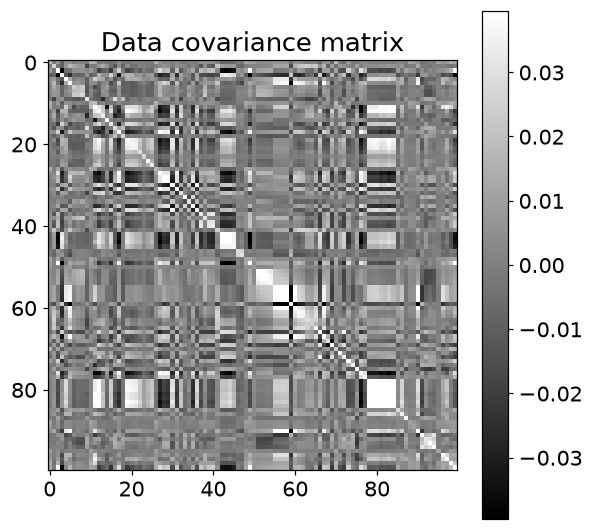

In [6]:
# compute the mean of each data feature
datamean = np.mean(dataMat,axis=0)

# mean-center the data using broadcasting
dataMatM = dataMat - datamean

# confirm that any given feature has mean=0 (or very close...)
print(np.mean(dataMatM[:,0]))


# Now to compute the covariance matrix
covMat = dataMatM.T @ dataMatM  # data matrix times its transpose
covMat /= (dataMatM.shape[0]-1) # divide by N-1

# dynamic color scaling
clim = np.max(np.abs(covMat)) * .2

# and show it
plt.figure(figsize=(6,6))
plt.imshow(covMat,vmin=-clim,vmax=clim,cmap='gray')
plt.colorbar()
plt.title('Data covariance matrix')
plt.savefig(ASSET / 'Figure_06_01.png',dpi=140)
plt.show()

### 선형변환

### 코드 06-06

- 원본: `original_py/LA4DS_ch06.py` 93–125행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

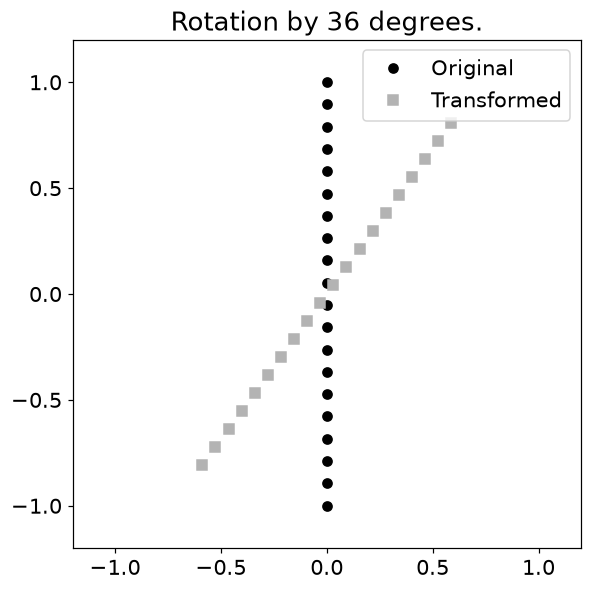

In [7]:
# Pure rotation matrix

# angle to rotate by
th = np.pi/5

# transformation matrix
T = np.array([ 
              [ np.cos(th),np.sin(th)],
              [-np.sin(th),np.cos(th)]
            ])


# original dots are a vertical line
x = np.linspace(-1,1,20)
origPoints = np.vstack( (np.zeros(x.shape),x) )


# apply the transformation
transformedPoints = T @ origPoints


# plot the points
plt.figure(figsize=(6,6))
plt.plot(origPoints[0,:],origPoints[1,:],'ko',label='Original')
plt.plot(transformedPoints[0,:],transformedPoints[1,:],'s',color=[.7,.7,.7],label='Transformed')

plt.axis('square')
plt.xlim([-1.2,1.2])
plt.ylim([-1.2,1.2])
plt.legend()
plt.title(f'Rotation by {np.rad2deg(th):.0f} degrees.')
plt.savefig(ASSET / 'Figure_06_02.png',dpi=140)
plt.show()

### 변환 애니메이션

### 코드 06-07

- 원본: `original_py/LA4DS_ch06.py` 129–165행.
- **보완**: 변환 애니메이션을 GIF로 저장해 Markdown에서도 볼 수 있게 했습니다.

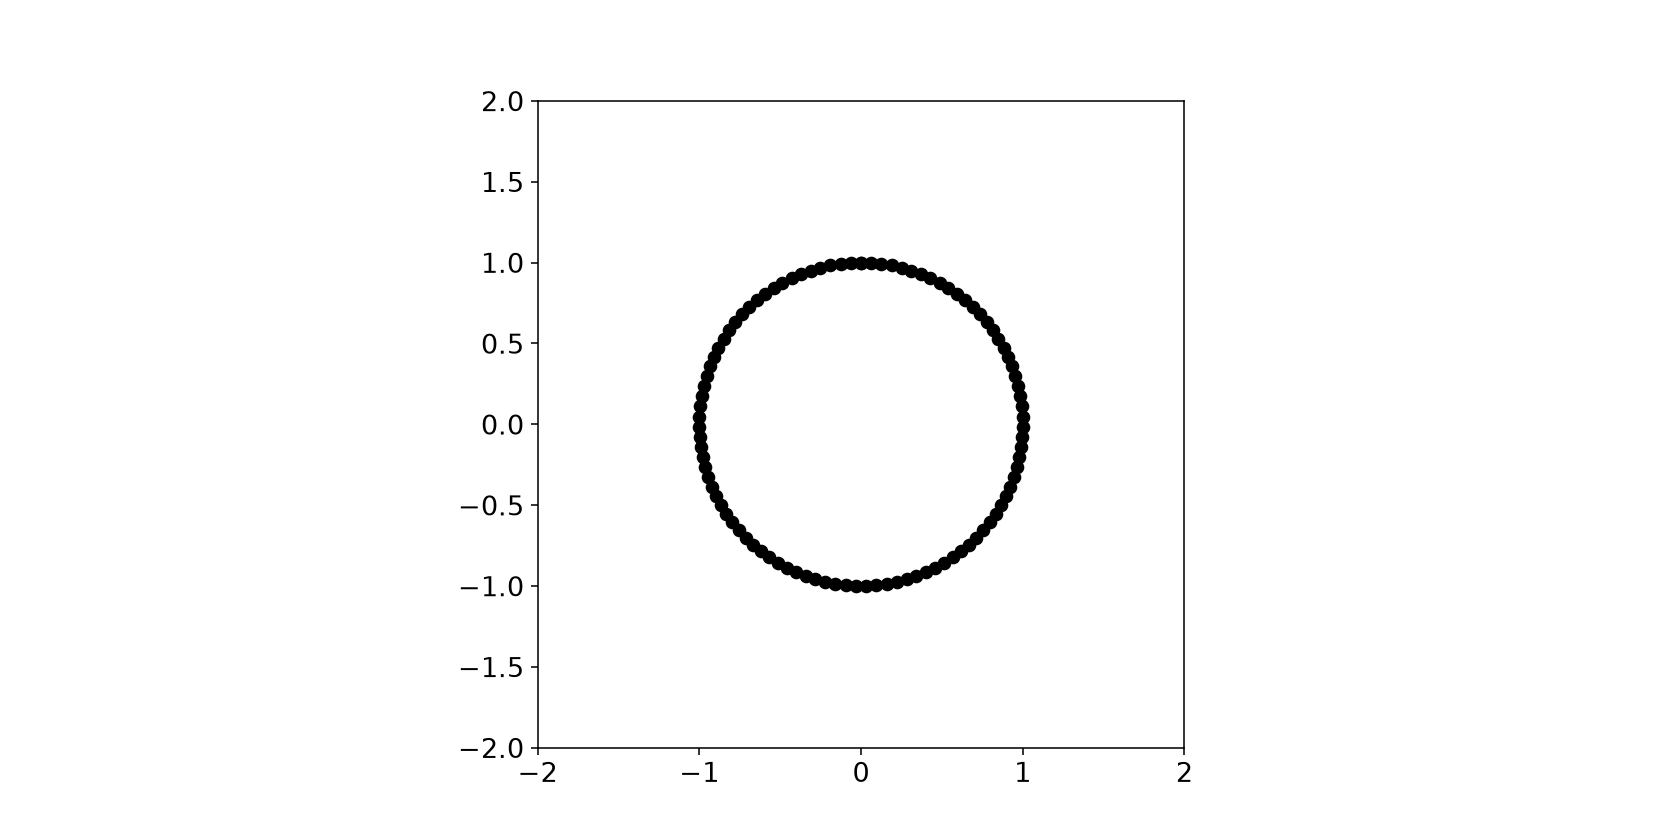

In [8]:
# function to update the axis on each iteration
def aframe(ph):

  # create the transformation matrix
  T = np.array([
                 [  1, 1-ph ],
                 [  0, 1    ]
                ])
  
  # apply the transformation to the points using matrix multiplication
  P = T@points

  # update the dots
  plth.set_xdata(P[0,:])
  plth.set_ydata(P[1,:])

  # export the plot handles
  return plth


# define XY points
theta  = np.linspace(0,2*np.pi,100)
points = np.vstack((np.sin(theta),np.cos(theta)))


# setup figure
fig,ax = plt.subplots(1,figsize=(12,6))
plth,  = ax.plot(np.cos(x),np.sin(x),'ko')
ax.set_aspect('equal')
ax.set_xlim([-2,2])
ax.set_ylim([-2,2])

# define values for transformation (note: clip off the final point for a smooth animation loop)
phi = np.linspace(-1,1-1/40,40)**2

# run animation!
anim = animation.FuncAnimation(fig, aframe, phi, interval=100, repeat=True)
anim.save(str(ASSET / 'animation_13.gif'), writer='pillow', fps=10)
from IPython.display import Image, display
display(Image(filename=str(ASSET / 'animation_13.gif')))
plt.close(fig)

### 이미지 합성곱

### 코드 06-08

- 원본: `original_py/LA4DS_ch06.py` 169–177행.

In [9]:
# image
imgN  = 20
image = np.random.randn(imgN,imgN)

# convolution kernel
kernelN = 7
Y,X     = np.meshgrid(np.linspace(-3,3,kernelN),np.linspace(-3,3,kernelN))
kernel  = np.exp( -(X**2+Y**2)/7 )
kernel  = kernel / np.sum(kernel) # normalize

### 코드 06-09

- 원본: `original_py/LA4DS_ch06.py` 179–202행.

In [10]:
# now for the convolution
halfKr = kernelN//2
convoutput = np.zeros((imgN+kernelN-1,imgN+kernelN-1))

imagePad = np.zeros(convoutput.shape)
imagePad[halfKr:-halfKr:1,halfKr:-halfKr:1] = image


# double for-loop over rows and columns (width and height of picture)
for rowi in range(halfKr,imgN+halfKr):
  for coli in range(halfKr,imgN+halfKr):

    # cut out a piece of the image
    pieceOfImg = imagePad[rowi-halfKr:rowi+halfKr+1:1,coli-halfKr:coli+halfKr+1:1]

    # dot product: element-wise multiply and sum
    dotprod = np.sum( pieceOfImg*kernel )

    # store the result for this pixel
    convoutput[rowi,coli] = dotprod


# trim off edges
convoutput = convoutput[halfKr:-halfKr:1,halfKr:-halfKr:1]

### 코드 06-10

- 원본: `original_py/LA4DS_ch06.py` 204–205행.

In [11]:
# using scipy
convoutput2 = convolve2d(image,kernel,mode='same')

### 코드 06-11

- 원본: `original_py/LA4DS_ch06.py` 207–224행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

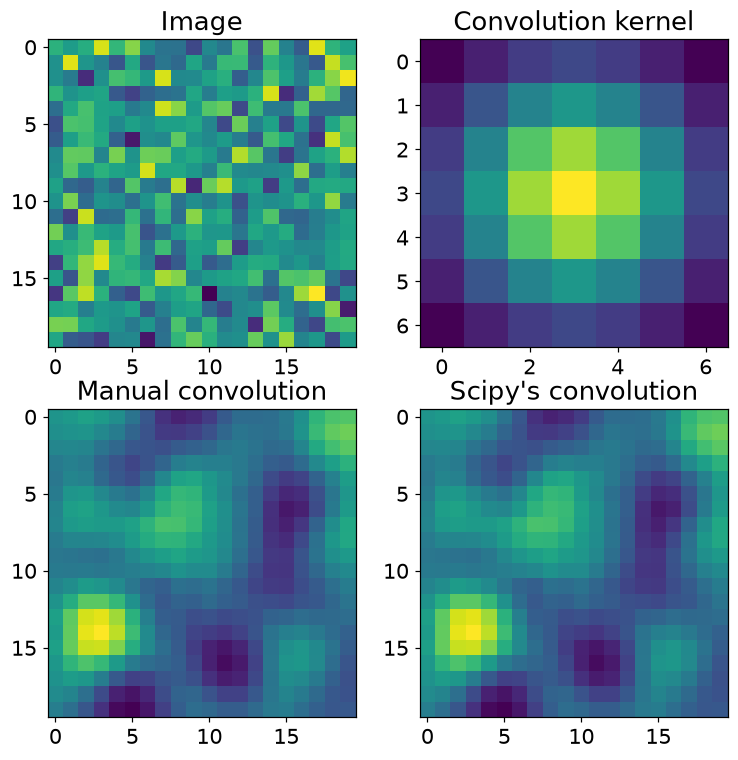

In [12]:
fig,ax = plt.subplots(2,2,figsize=(8,8))

ax[0,0].imshow(image)
ax[0,0].set_title('Image')

ax[0,1].imshow(kernel)
ax[0,1].set_title('Convolution kernel')

ax[1,0].imshow(convoutput)
ax[1,0].set_title('Manual convolution')

ax[1,1].imshow(convoutput2)
ax[1,1].set_title("Scipy's convolution")

# for i in ax.flatten(): i.axis('off')

plt.savefig(ASSET / 'Figure_06_04b.png',dpi=140)
plt.show()

### 코드 06-12

- 원본: `original_py/LA4DS_ch06.py` 228–244행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 이미지 입력을 코드로 직접 생성한 도형 그림으로 교체했습니다. 변수명 bathtub은 원본 연결을 위해 유지하며 박물관 사진의 결과가 아닙니다.

(240, 320, 3)
(240, 320)


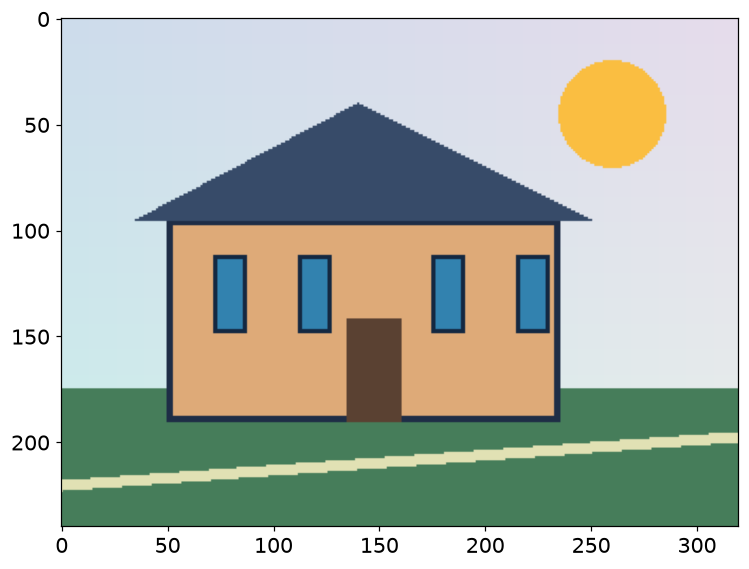

In [13]:
# read a pic from the web
bathtub = io.imread(DATA / 'generated_scene.png')

# check the size
print(bathtub.shape)

# let's see what the famous Bathtub Museum looks like
fig = plt.figure(figsize=(10,6))
plt.imshow(bathtub)
plt.savefig(ASSET / 'Figure_06_05a.png',dpi=140)
plt.show()

# transform image to 2D for convenience (not necessary for convolution!)
bathtub2d = color.rgb2gray(bathtub)

# check the size again
print(bathtub2d.shape)

### 코드 06-13

- 원본: `original_py/LA4DS_ch06.py` 246–259행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

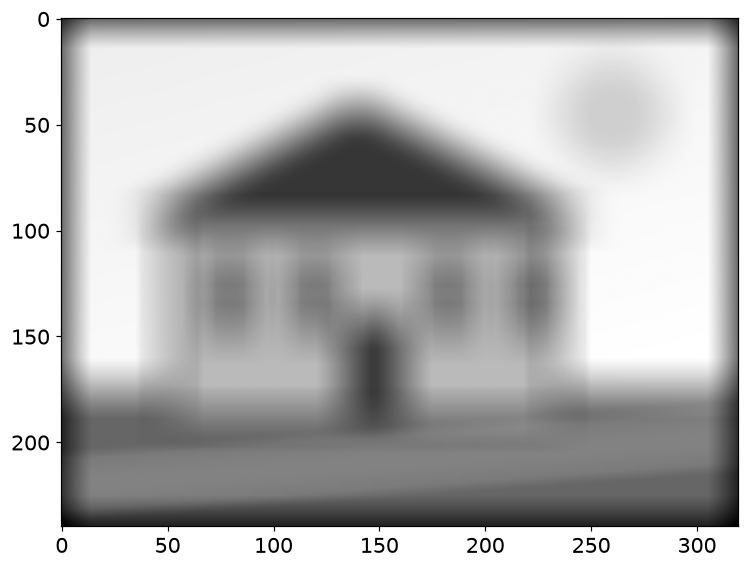

In [14]:
# convolution kernel
kernelN = 29 # a bit bigger than in the previous example... feel free to change this parameter!
Y,X     = np.meshgrid(np.linspace(-3,3,kernelN),np.linspace(-3,3,kernelN))
kernel  = np.exp( -(X**2+Y**2)/20 )
kernel  = kernel / np.sum(kernel) # normalize the kernel to integrate to 1, which preserves the numerical scale of the image.


# smoothing via Gaussian convolution
smooth_bathtub = convolve2d(bathtub2d,kernel,mode='same')

fig = plt.figure(figsize=(10,6))
plt.imshow(smooth_bathtub,cmap='gray')
plt.savefig(ASSET / 'Figure_06_05b.png',dpi=140)
plt.show()

## 연습문제 1 · 공분산을 상관으로 변환

- **목표**: 단위가 다른 변수의 크기 효과를 제거합니다.
- **풀이 순서**: 공분산 대각선에서 표준편차를 구하고 역수 대각행렬 S로 SCS를 계산합니다. 공분산과 상관 열지도를 비교합니다.
- **결과 해석**: 상관의 대각선은 1입니다. 두 변수 이름을 읽을 때는 숫자형 열 선택과 추가 열 제거 후의 목록을 써야 합니다.

### 코드 06-14

- 원본: `original_py/LA4DS_ch06.py` 263–289행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

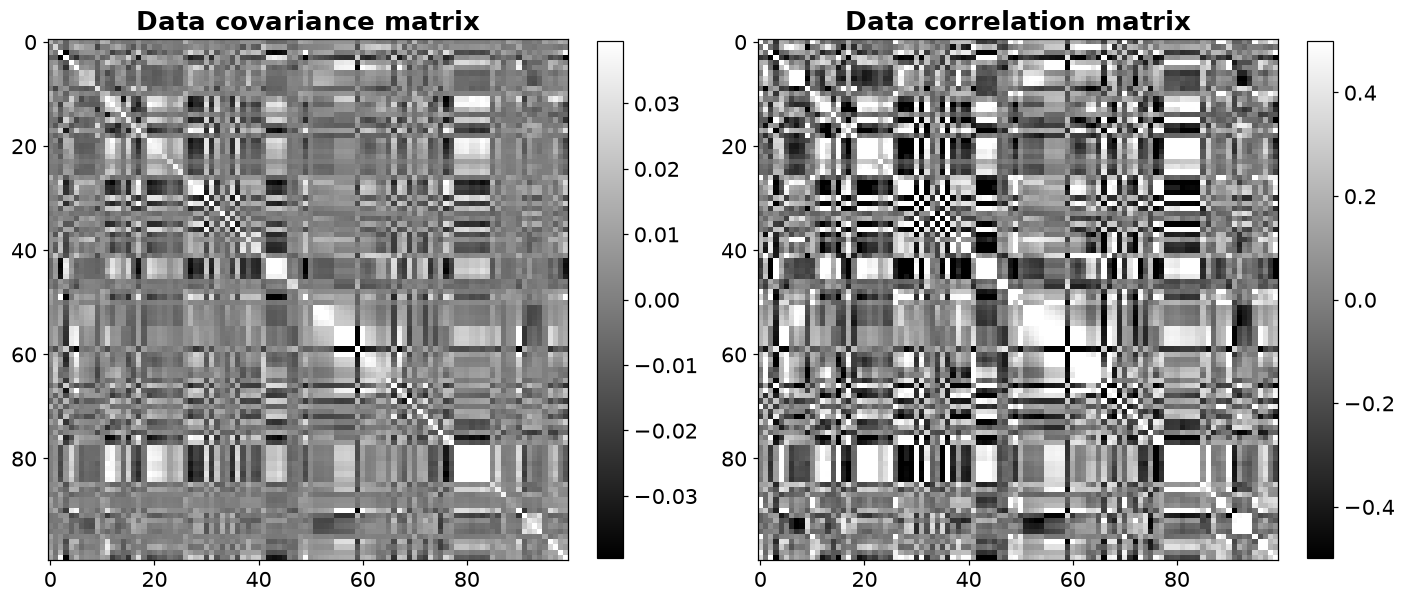

In [15]:
# Diagonal matrix of inverse standard deviations
variances = np.diag(covMat) # variances are the diagonals of a covariance
standard_devs = np.sqrt( variances )
S = np.diag( 1/standard_devs )

# you can also do this in one line:
#S = np.diag( 1/np.sqrt(np.diag(covMat)) )


# compute the correlation matrix
corrMat = S @ covMat @ S


# and show the matrices
fig,axs = plt.subplots(1,2,figsize=(13,6))
h1 = axs[0].imshow(covMat,vmin=-clim,vmax=clim,cmap='gray')
axs[0].set_title('Data covariance matrix',fontweight='bold')

h2 = axs[1].imshow(corrMat,vmin=-.5,vmax=.5,cmap='gray')
axs[1].set_title('Data correlation matrix',fontweight='bold')

fig.colorbar(h1,ax=axs[0],fraction=.045)
fig.colorbar(h2,ax=axs[1],fraction=.045)

plt.tight_layout()
plt.savefig(ASSET / 'Figure_06_06.png',dpi=140)
plt.show()

### 코드 06-15

- 원본: `original_py/LA4DS_ch06.py` 291–297행.
- **보완**: 상관계수에 대응하는 열 이름을 전처리 후 열 목록에서 가져오도록 수정했습니다.

In [16]:
# a bit of code to explore specific pairs of correlations

# here list two indices into the correlation matrix (row, col)
i,j = 43,17

# the printed tuple will show the correlation and the pairs of variables
corrMat[i,j], numberDataset.drop(['state','fold'],axis=1).columns[i], numberDataset.drop(['state','fold'],axis=1).columns[j]

Out[16]: (np.float64(-0.7603179079300488), 'PctKids2Par', 'pctWPubAsst')


## 연습문제 2 · NumPy와 상관행렬 비교

- **목표**: 직접 구현한 상관행렬이 라이브러리와 같은지 확인합니다.
- **풀이 순서**: 관측치×변수 행렬을 전치해 corrcoef에 넣거나 rowvar=False를 사용합니다. 두 행렬과 차이를 그립니다.
- **결과 해석**: 차이는 0 근처입니다. 전치하지 않으면 변수 대신 관측치끼리의 상관을 구하게 됩니다. 함수 문서에서 기본 축 규칙을 확인합니다.

### 코드 06-16

- 원본: `original_py/LA4DS_ch06.py` 301–322행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

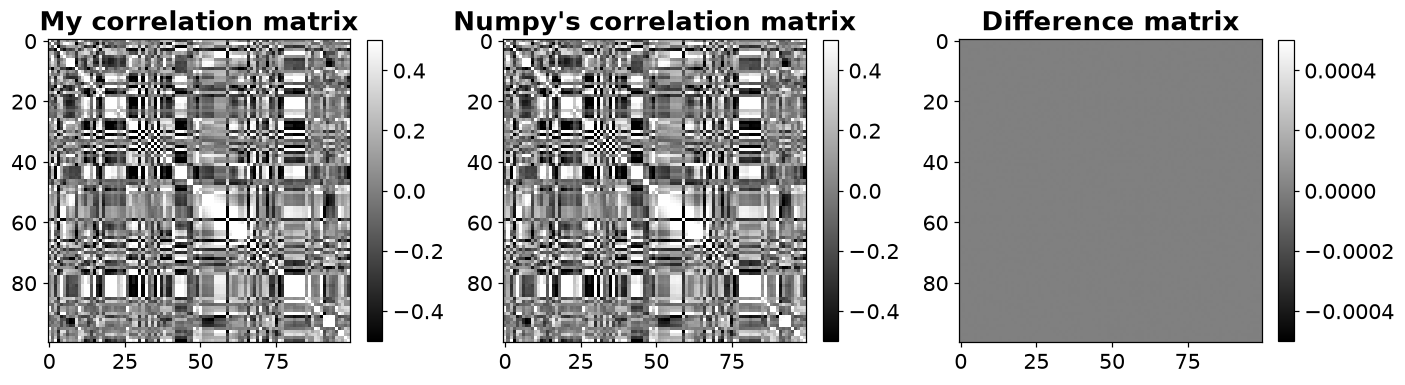

In [17]:
# numpy's correlation function (note transposing the matrix!)
corrMat_np = np.corrcoef(dataMat.T)


# and show it
fig,axs = plt.subplots(1,3,figsize=(13,6))
h1 = axs[0].imshow(corrMat,vmin=-.5,vmax=.5,cmap='gray')
axs[0].set_title('My correlation matrix',fontweight='bold')

h2 = axs[1].imshow(corrMat_np,vmin=-.5,vmax=.5,cmap='gray')
axs[1].set_title("Numpy's correlation matrix",fontweight='bold')

h3 = axs[2].imshow(corrMat_np-corrMat,vmin=-.0005,vmax=.0005,cmap='gray')
axs[2].set_title('Difference matrix',fontweight='bold')

fig.colorbar(h1,ax=axs[0],fraction=.045)
fig.colorbar(h2,ax=axs[1],fraction=.045)
fig.colorbar(h3,ax=axs[2],fraction=.045)

plt.tight_layout()
plt.savefig(ASSET / 'Figure_06_07.png',dpi=140)
plt.show()

### 코드 06-17

- 원본: `original_py/LA4DS_ch06.py` 324–324행.
- **보완**: IPython 소스 보기 명령을 함수 시그니처와 설명 출력으로 변환했습니다. 전체 소스는 inspect.getsource로 확인할 수 있습니다.

In [18]:
import inspect
print(inspect.signature(np.corrcoef))
print(inspect.getdoc(np.corrcoef).split("\n\n")[0])

(x, y=None, rowvar=True, *, dtype=None)
Return Pearson product-moment correlation coefficients.


### 코드 06-18

- 원본: `original_py/LA4DS_ch06.py` 326–326행.
- **보완**: IPython 소스 보기 명령을 함수 시그니처와 설명 출력으로 변환했습니다. 전체 소스는 inspect.getsource로 확인할 수 있습니다.

In [19]:
import inspect
print(inspect.signature(np.cov))
print(inspect.getdoc(np.cov).split("\n\n")[0])

(m, y=None, rowvar=True, bias=False, ddof=None, fweights=None, aweights=None, *, dtype=None)
Estimate a covariance matrix, given data and weights.


## 연습문제 3 · 원에 선형변환 적용

- **목표**: 비등방 확대·축소와 전단을 관찰합니다.
- **풀이 순서**: 단위원의 점을 2×N으로 쌓고 $T=\begin{bmatrix}1&0.5\\0&0.5\end{bmatrix}$를 왼쪽에 곱합니다.
- **결과 해석**: 원은 타원으로 변합니다. 모든 점에 같은 행렬을 적용하므로 직선성·원점은 보존되지만 길이와 각도는 일반적으로 바뀝니다.

### 코드 06-19

- 원본: `original_py/LA4DS_ch06.py` 330–356행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

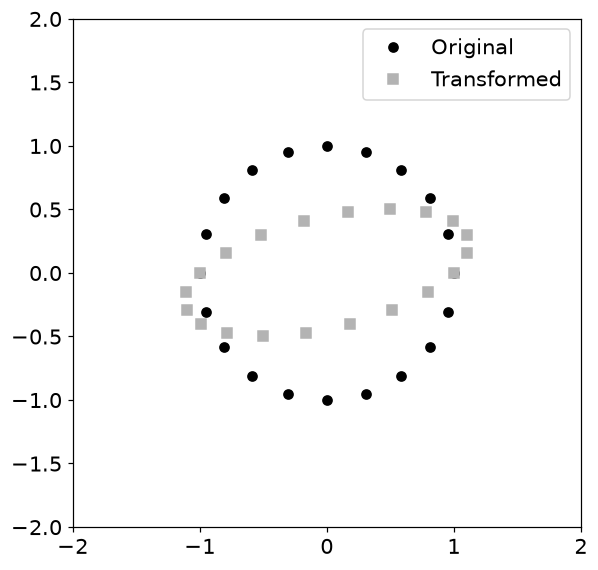

In [20]:
# Transformation matrix
T = np.array([ 
              [1,.5],
              [0,.5]
            ])


# define the set of points (a circle)
theta = np.linspace(0,2*np.pi-2*np.pi/20,20)
origPoints = np.vstack( (np.cos(theta),np.sin(theta)) )

# apply transformation
transformedPoints = T @ origPoints


# plot the points
plt.figure(figsize=(6,6))
plt.plot(origPoints[0,:],origPoints[1,:],'ko',label='Original')
plt.plot(transformedPoints[0,:],transformedPoints[1,:],'s',
         color=[.7,.7,.7],label='Transformed')

plt.axis('square')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.legend()
plt.savefig(ASSET / 'Figure_06_08.png',dpi=140)
plt.show()

## 연습문제 4 · 변환 애니메이션

- **목표**: 행렬 원소가 변하면 전체 곡선이 함께 변하는지 관찰합니다.
- **풀이 순서**: 사인·코사인 곡선 좌표에 diag(1-ph/3,ph)를 적용하고 ph에 따른 프레임을 GIF로 저장합니다.
- **결과 해석**: 가로와 세로 배율이 독립적으로 달라집니다. ph=0에서는 세로 방향이 사라져 역변환이 불가능합니다.

### 코드 06-20

- 원본: `original_py/LA4DS_ch06.py` 360–379행.

In [21]:
# function to draw the plots
def aframe(ph):

  # create the transformation matrix
  T = np.array([ [  1-ph/3,0 ],
                 [  0,ph   ] ])
  
  # apply the transformation to the points using matrix multiplication
  P1 = T@Y1
  P2 = T@Y2

  # update the lower/upper lines
  plth1.set_xdata(P1[0,:])
  plth1.set_ydata(P1[1,:])

  plth2.set_xdata(P2[0,:])
  plth2.set_ydata(P2[1,:])

  # export the plot handles
  return (plth1,plth2)

### 코드 06-21

- 원본: `original_py/LA4DS_ch06.py` 381–397행.
- **보완**: 변환 애니메이션을 GIF로 저장해 Markdown에서도 볼 수 있게 했습니다.

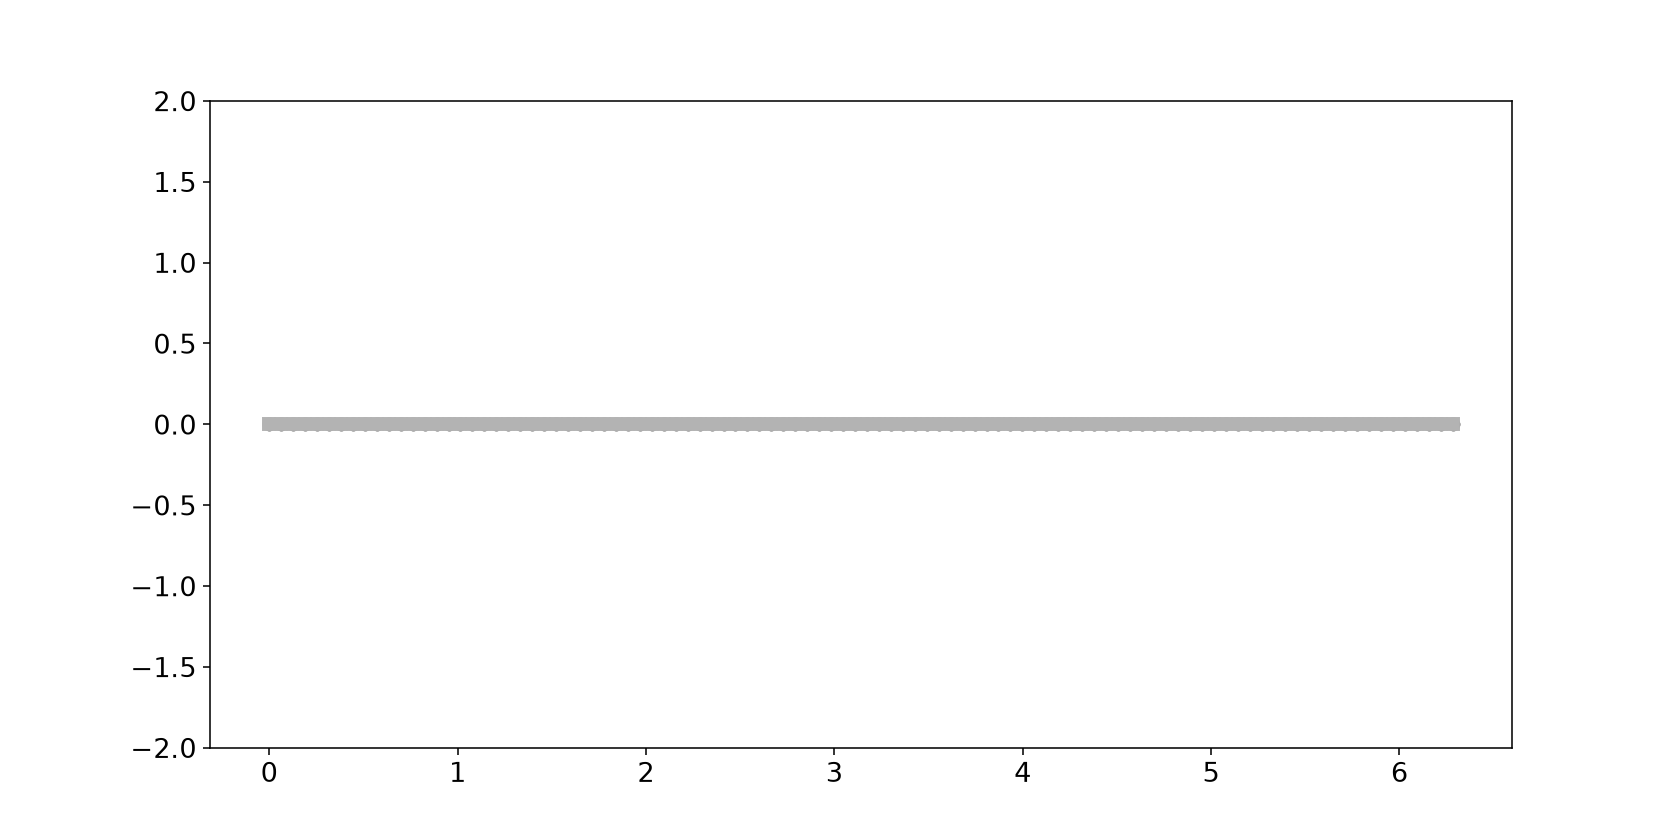

In [22]:
# define XY points
th = np.linspace(0,2*np.pi,100) # th = theta (angles)
Y1 = np.vstack((th,np.cos(th)))
Y2 = np.vstack((th,np.sin(th)))


# setup figure
fig,ax = plt.subplots(1,figsize=(12,6))

plth1, = ax.plot(Y1[0,:],Y1[1,:],'ko')
plth2, = ax.plot(Y2[0,:],Y2[1,:],'s',color=[.7,.7,.7])
ax.set_ylim([-2,2])


# define phases and run animation
phi = 1-np.linspace(-1,1-1/40,40)**2
anim = animation.FuncAnimation(fig, aframe, phi, interval=50, repeat=True)
anim.save(str(ASSET / 'animation_38.gif'), writer='pillow', fps=10)
from IPython.display import Image, display
display(Image(filename=str(ASSET / 'animation_38.gif')))
plt.close(fig)

## 연습문제 5 · RGB 채널별 평활화

- **목표**: 컬러 이미지도 채널별 행렬로 처리할 수 있음을 확인합니다.
- **풀이 순서**: 각 RGB 채널에 같은 커널로 2차원 합성곱을 적용하고 다시 세 채널을 모읍니다. 실수와 uint8 dtype을 비교합니다.
- **결과 해석**: 색을 섞는 것이 아니라 각 채널 내부에서 공간적으로 평균냅니다. 표시를 위한 형변환은 계산의 정밀도를 낮추므로 중간 계산은 실수로 유지합니다.

### 코드 06-22

- 원본: `original_py/LA4DS_ch06.py` 401–411행.

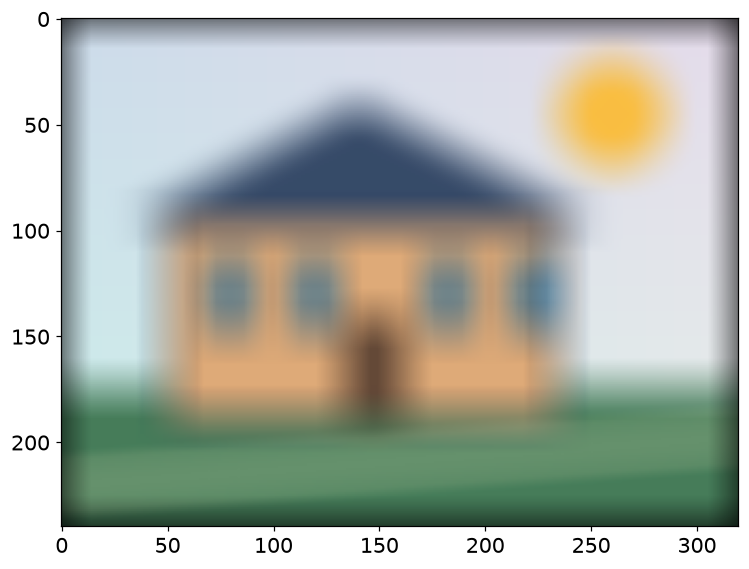

In [23]:
# initialize smoothed image
smooth_bathtub = np.zeros(bathtub.shape)

# smooth each layer individually
for i in range(smooth_bathtub.shape[2]):
  smooth_bathtub[:,:,i] = convolve2d(bathtub[:,:,i],kernel,mode='same')


fig = plt.figure(figsize=(10,6))
plt.imshow(smooth_bathtub.astype(np.uint8))
plt.show()

### 코드 06-23

- 원본: `original_py/LA4DS_ch06.py` 413–415행.

In [24]:
# check data types
print( smooth_bathtub.dtype )
print( smooth_bathtub.astype(np.uint8).dtype )

float64
uint8


## 연습문제 6 · 채널마다 다른 커널

- **목표**: RGB에 서로 다른 평활화 강도를 적용합니다.
- **풀이 순서**: 각 채널에 폭 0.5,5,50을 넣은 가우시안 커널을 만들고 정규화해 적용합니다.
- **결과 해석**: 폭이 큰 커널은 주변 픽셀을 더 넓게 섞습니다. 채널마다 다르게 흐려지므로 색 가장자리도 달라집니다. 원본의 두 번째 Exercise 5 표기를 여기서는 6으로 정리했습니다.

### 코드 06-24

- 원본: `original_py/LA4DS_ch06.py` 417–450행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

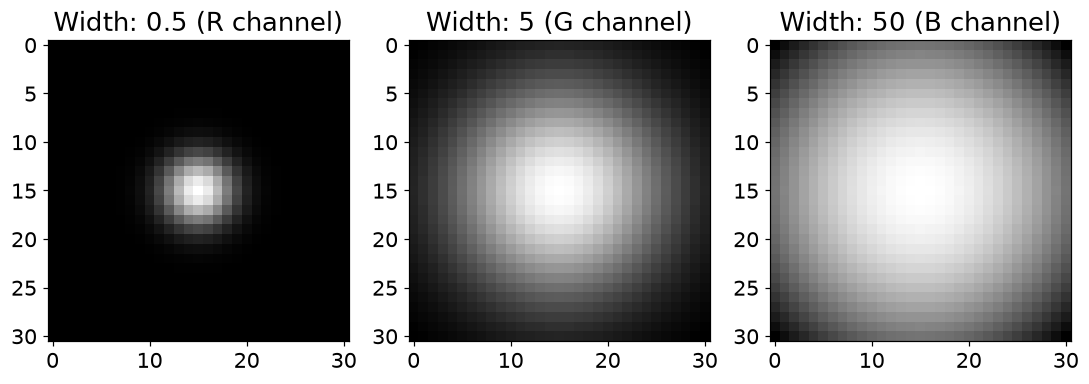

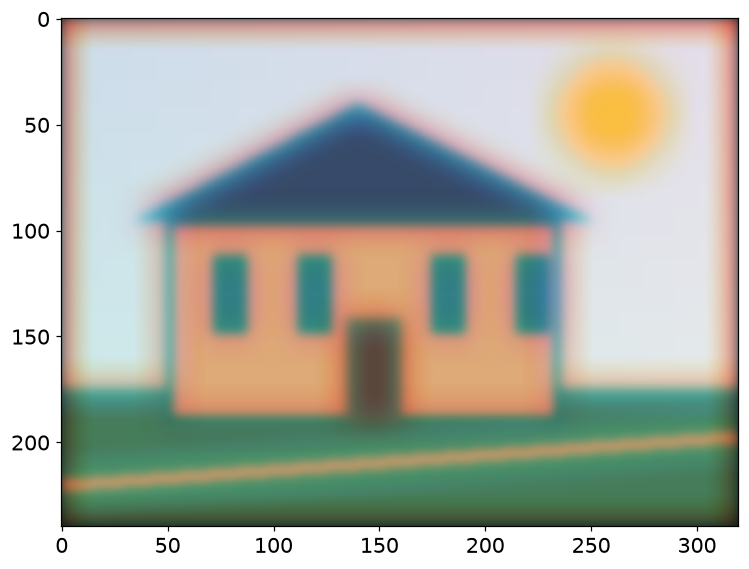

In [25]:
# layer-specific kernel widths
kernelN = 31
kernelWidths = [.5,5,50]


# initialize smoothed image
smooth_bathtub = np.zeros(bathtub.shape)

# to show the kernels
_,axs = plt.subplots(1,3,figsize=(12,6))

# smooth each layer individually
for i in range(smooth_bathtub.shape[2]):

  # create kernel
  Y,X     = np.meshgrid(np.linspace(-3,3,kernelN),np.linspace(-3,3,kernelN))
  kernel  = np.exp( -(X**2+Y**2) / kernelWidths[i] )
  kernel  = kernel / np.sum(kernel) # normalize
  
  # visualize the kernels
  axs[i].imshow(kernel,cmap='gray')
  axs[i].set_title(f'Width: {kernelWidths[i]} ({"RGB"[i]} channel)')

  # now run convolution
  smooth_bathtub[:,:,i] = convolve2d(bathtub[:,:,i],kernel,mode='same')

plt.savefig(ASSET / 'Figure_06_10.png',dpi=140)
plt.show() # close the kernels figure


# show the smoothed image
fig = plt.figure(figsize=(10,6))
plt.imshow(smooth_bathtub.astype(np.uint8))
plt.show()

## 연습문제 7 · 방향별 경계 검출

- **목표**: 수직·수평 변화에 반응하는 커널을 비교합니다.
- **풀이 순서**: 3×3 부호 교대 커널 두 개를 만들고 회색조 이미지에 convolve2d를 적용합니다.
- **결과 해석**: 수직 커널은 좌우 밝기 차이, 수평 커널은 상하 밝기 차이에 민감합니다. 응답의 부호는 변화 방향과 커널 뒤집힘에 좌우됩니다.

### 코드 06-25

- 원본: `original_py/LA4DS_ch06.py` 454–464행.

In [26]:
# Create two feature-detection kernels

# vertical kernel
VK = np.array([ [1,0,-1],
                [1,0,-1],
                [1,0,-1] ])

# horizontal kernel
HK = np.array([ [ 1, 1, 1],
                [ 0, 0, 0],
                [-1,-1,-1] ])

### 코드 06-26

- 원본: `original_py/LA4DS_ch06.py` 466–486행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

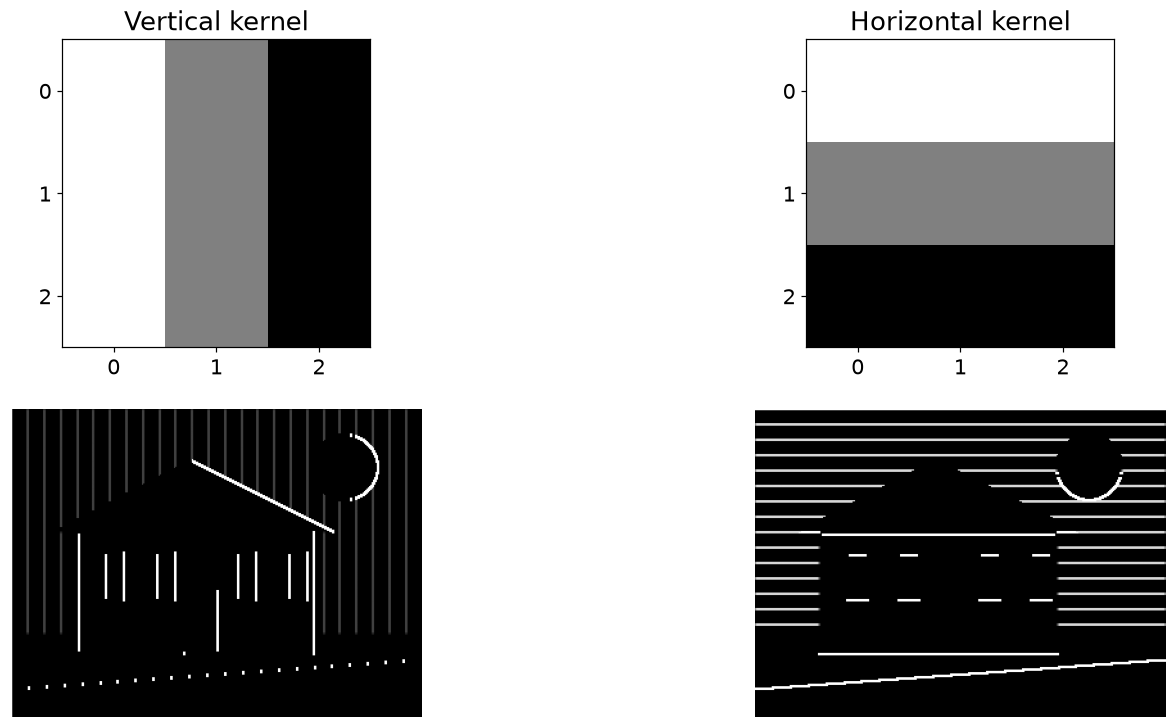

In [27]:
fig,ax = plt.subplots(2,2,figsize=(16,8))

ax[0,0].imshow(VK,cmap='gray')
ax[0,0].set_title('Vertical kernel')
ax[0,0].set_yticks(range(3))

ax[0,1].imshow(HK,cmap='gray')
ax[0,1].set_title('Horizontal kernel')
ax[0,1].set_yticks(range(3))

# run convolution and show the result
convres = convolve2d(bathtub2d,VK,mode='same')
ax[1,0].imshow(convres,cmap='gray',vmin=0,vmax=.01)
ax[1,0].axis('off')

convres = convolve2d(bathtub2d,HK,mode='same')
ax[1,1].imshow(convres,cmap='gray',vmin=0,vmax=.01)
ax[1,1].axis('off')

plt.savefig(ASSET / 'Figure_06_11.png',dpi=140)
plt.show()

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [28]:
_X=np.array([[1.,2.],[2.,4.],[3.,6.]])
_Xc=_X-_X.mean(axis=0); _C=_Xc.T@_Xc/(len(_X)-1)
print('공분산:\n',_C)
assert np.allclose(_C,np.cov(_X,rowvar=False))
assert np.allclose(corrMat,corrMat_np)
print('원자료의 직접 계산 상관과 NumPy 최대 차이:',np.max(np.abs(corrMat-corrMat_np)))
assert np.allclose(convoutput,convoutput2)
print('대칭 커널의 수동 계산과 SciPy 합성곱 일치: 통과')


공분산:
 [[1. 2.]
 [2. 4.]]
원자료의 직접 계산 상관과 NumPy 최대 차이: 4.440892098500626e-16
대칭 커널의 수동 계산과 SciPy 합성곱 일치: 통과
